# **EDA: UrbanSound8K**

Análisis exploratorio del dataset [UrbanSound8K](https://www.kaggle.com/datasets/chrisfilo/urbansound8k), que contiene **8.732 fragmentos de audio** de hasta 4 segundos, etiquetados y extraídos de grabaciones reales subidas a la plataforma Freesound. Cada fragmento pertenece a una de **10 clases de sonidos urbanos** y tiene un archivo de metadatos llamado UrbanSound8K.csv. Es el dataset más citado en la literatura de clasificación de audio urbano.

Los autores del dataset advierten que no debemos reordenar los datos. El dataset viene ya dividido en 10 folds y los fragmentos del mismo archivo original siempre están en el mismo fold, evitando data leakage.

**Columnas del dataset:**
| Columna | Descripción |
|---|---|
| `slice_file_name` | Nombre del archivo de audio |
| `fsID` | ID de la fuente original en Freesound |
| `start` | Inicio del clip dentro del audio original (segundos) |
| `end` | Fin del clip dentro del audio original (segundos) |
| `salience` | 1 = sonido en primer plano, 2 = sonido de fondo |
| `fold` | Fold (1–10) para validación cruzada |
| `classID` | ID numérico de la clase (0–9) |
| `class` | Nombre de la clase |


| Clase | Relevancia para el sistema de alertas |
|---|---|
| `gun_shot` | crítica |
| `siren` | crítica |
| `car_horn` | alta |
| `dog_bark` | media |
| `drilling` | media |
| `jackhammer` | media |
| `engine_idling` | baja |
| `children_playing` | baja |
| `street_music` | baja |
| `air_conditioner` | baja |

## **1. Dependencias**

In [1]:
from pandas.core.groupby.generic import DataFrameGroupBy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

## **2. Carga del dataset**

In [2]:
# Estilo general
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
# Carga del dataset
df = pd.read_csv("/content/UrbanSound8K.csv")
df

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
...,...,...,...,...,...,...,...,...
8727,99812-1-2-0.wav,99812,159.522205,163.522205,2,7,1,car_horn
8728,99812-1-3-0.wav,99812,181.142431,183.284976,2,7,1,car_horn
8729,99812-1-4-0.wav,99812,242.691902,246.197885,2,7,1,car_horn
8730,99812-1-5-0.wav,99812,253.209850,255.741948,2,7,1,car_horn


In [4]:
# Feature adicional
df["duration"] = df["end"] - df["start"]

print(f"Shape: {df.shape}")

Shape: (8732, 9)


In [5]:
df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class,duration
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark,0.317551
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing,4.000000
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing,4.000000
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing,4.000000
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing,4.000000


In [6]:
df.tail()

,slice_file_name,fsID,start,end,salience,fold,classID,class,duration
8727,99812-1-2-0.wav,99812,159.522205,163.522205,2,7,1,car_horn,4.000000
8728,99812-1-3-0.wav,99812,181.142431,183.284976,2,7,1,car_horn,2.142545
8729,99812-1-4-0.wav,99812,242.691902,246.197885,2,7,1,car_horn,3.505983
8730,99812-1-5-0.wav,99812,253.209850,255.741948,2,7,1,car_horn,2.532098
8731,99812-1-6-0.wav,99812,332.289233,334.821332,2,7,1,car_horn,2.532099


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
 8   duration         8732 non-null   float64
dtypes: float64(3), int64(4), object(2)
memory usage: 614.1+ KB


## **3. Estructura y tipos de datos**

In [8]:
df.columns

Index(['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold',
       'classID', 'class', 'duration'],
      dtype='object')

In [9]:
print("Valores nulos")
df.isnull().sum()

Valores nulos


,0
slice_file_name,0
fsID,0
start,0
end,0
salience,0
fold,0
classID,0
class,0
duration,0


In [10]:
print("Valores faltantes del dataframe")
df.isna().sum().sum()

Valores faltantes del dataframe


np.int64(0)

In [11]:
print("Valores faltantes para cada columna")
df.isna().sum()

Valores faltantes para cada columna


,0
slice_file_name,0
fsID,0
start,0
end,0
salience,0
fold,0
classID,0
class,0
duration,0


In [12]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
slice_file_name,0.0
fsID,0.0
start,0.0
end,0.0
salience,0.0
fold,0.0
classID,0.0
class,0.0
duration,0.0


In [13]:
print("Tipos de datos")
df.dtypes

Tipos de datos


,0
slice_file_name,object
fsID,int64
start,float64
end,float64
salience,int64
fold,int64
classID,int64
class,object
duration,float64


In [14]:
print("Estadísticas descriptivas")
df.describe().round(3)

Estadísticas descriptivas


,fsID,start,end,salience,fold,classID,duration
count,8732.000,8732.000,8732.000,8732.000,8732.000,8732.000,8732.000
mean,116033.494,38.645,42.253,1.347,5.386,4.593,3.608
std,57991.017,74.292,74.370,0.476,2.847,2.895,0.974
min,344.000,0.000,0.106,1.000,1.000,0.000,0.055
25%,69942.250,3.000,6.839,1.000,3.000,2.000,4.000
50%,118279.000,10.376,14.000,1.000,5.000,4.000,4.000
75%,166942.000,35.131,38.867,2.000,8.000,7.000,4.000
max,209992.000,600.125,604.125,2.000,10.000,9.000,4.000


In [15]:
print("Posibles variables categóricas")
df.select_dtypes(include=['object']).columns

Posibles variables categóricas


Index(['slice_file_name', 'class'], dtype='object')

## **4. Distribución de clases**

- El dataset está **desbalanceado**: `gun_shot` (374) y `car_horn` (429) tienen menos de la mitad de muestras que las clases mayoritarias (1000 cada una).

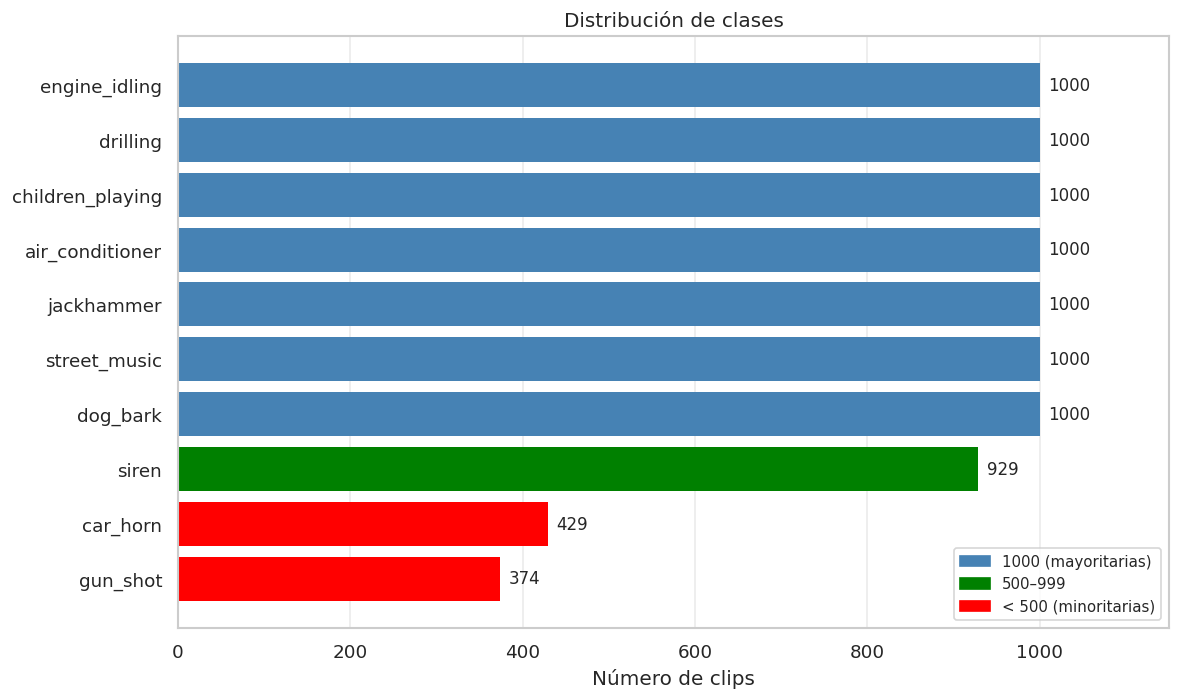

                  count   pct
class                        
gun_shot            374   4.3
car_horn            429   4.9
siren               929  10.6
dog_bark           1000  11.5
street_music       1000  11.5
jackhammer         1000  11.5
air_conditioner    1000  11.5
children_playing   1000  11.5
drilling           1000  11.5
engine_idling      1000  11.5


In [16]:
class_counts = df["class"].value_counts().sort_values()

colors = ["red" if v < 500 else "green" if v < 1000 else "steelblue"
          for v in class_counts.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(class_counts.index, class_counts.values, color=colors, edgecolor="none")

for bar, val in zip(bars, class_counts.values):
    ax.text(val + 10, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", ha="left", fontsize=10)

ax.set_xlabel("Número de clips")
ax.set_title("Distribución de clases")
ax.set_xlim(0, 1150)
ax.grid(axis="x", alpha=0.4)
ax.grid(axis="y", alpha=0)

from matplotlib.patches import Patch
legend = [Patch(color="steelblue", label="1000 (mayoritarias)"),
          Patch(color="green", label="500–999"),
          Patch(color="red", label="< 500 (minoritarias)")]
ax.legend(handles=legend, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

print(class_counts.to_frame("count").assign(pct=lambda x: (x["count"] / len(df) * 100).round(1)))

## **5. Distribución por fold**

- Los 10 folds están bastante equilibrados (806–990 clips), lo que valida el uso
de **10-fold cross-validation**, tal como recomiendan los autores originales.

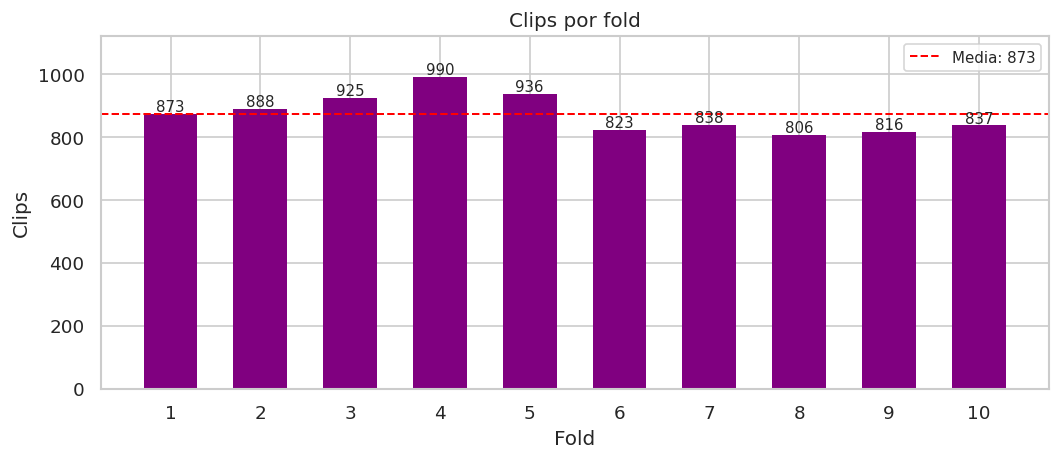

In [17]:
fold_counts = df["fold"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(fold_counts.index, fold_counts.values, color="purple",
       edgecolor="none", width=0.6)
ax.axhline(fold_counts.mean(), color="red", linestyle="--",
           linewidth=1.2, label=f"Media: {fold_counts.mean():.0f}")

for x, y in zip(fold_counts.index, fold_counts.values):
    ax.text(x, y + 8, str(y), ha="center", fontsize=9)

ax.set_xlabel("Fold")
ax.set_ylabel("Clips")
ax.set_title("Clips por fold")
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 1120)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## **6. Distribución de clases por fold (heatmap)**


- Será útil para detectar si alguna clase está mal repartida entre folds.

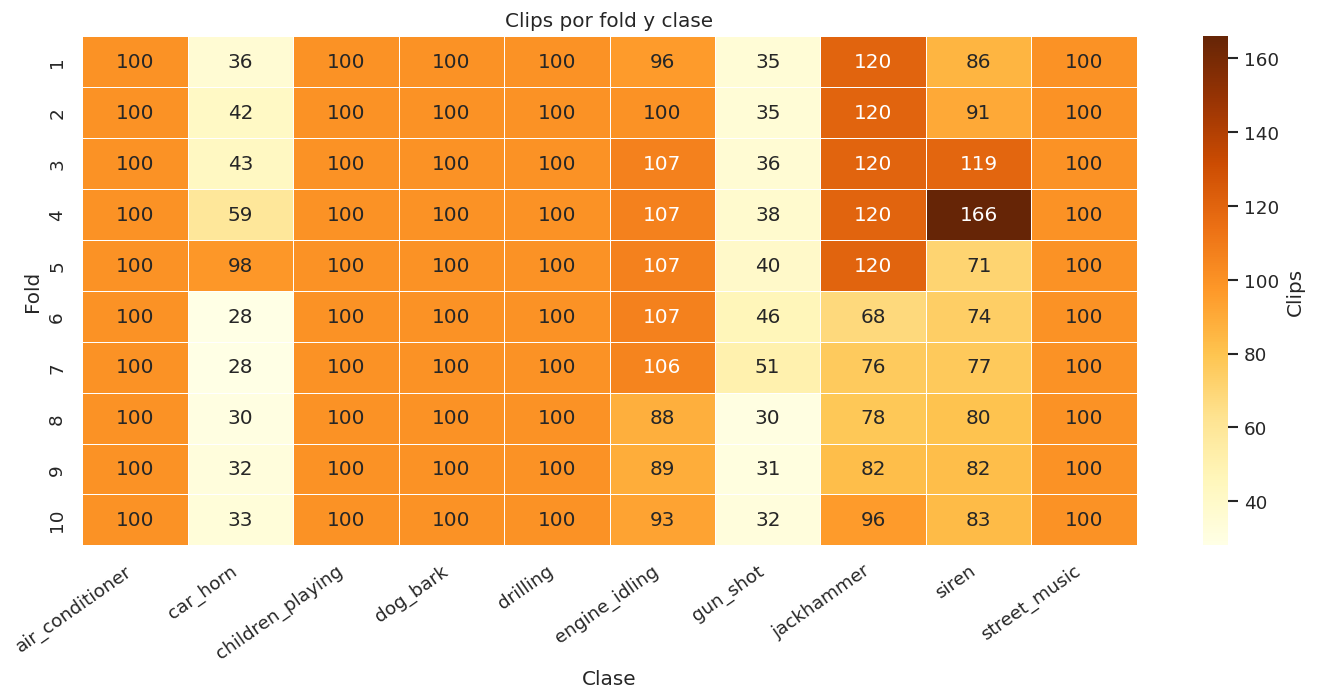

In [18]:
pivot = df.groupby(["fold", "class"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrBr",
            linewidths=0.4, ax=ax, cbar_kws={"label": "Clips"})
ax.set_title("Clips por fold y clase")
ax.set_xlabel("Clase")
ax.set_ylabel("Fold")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

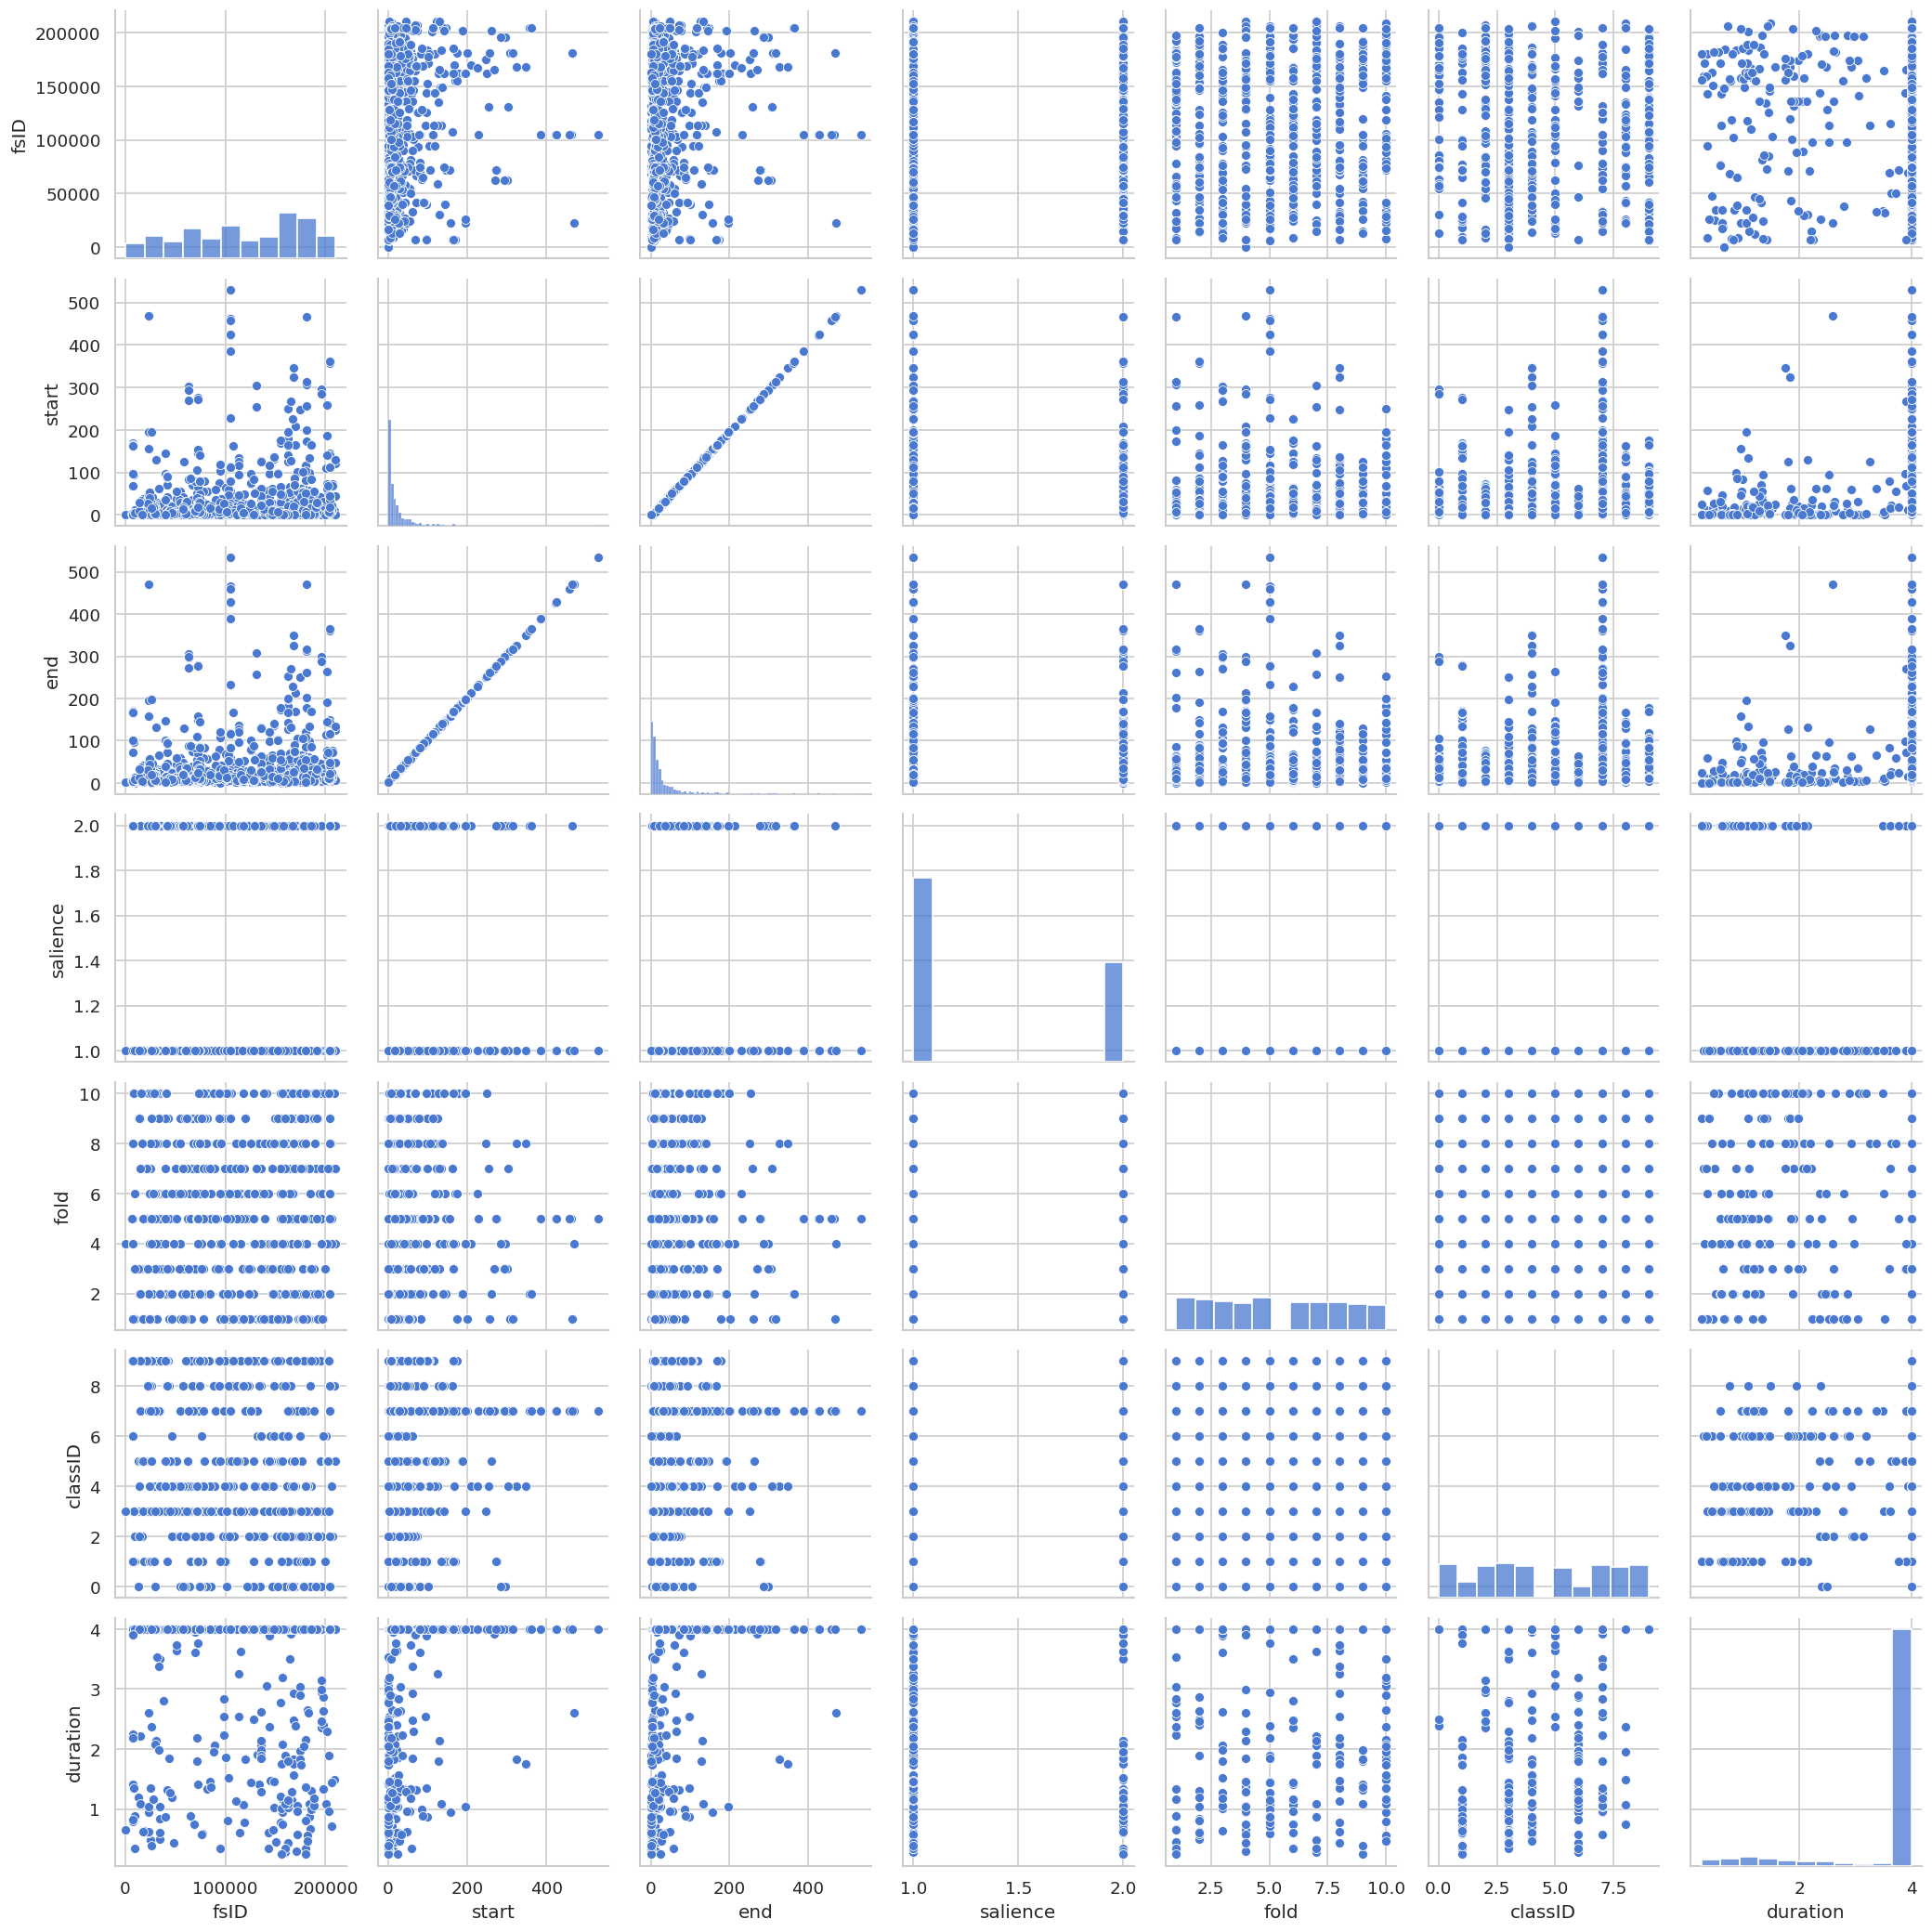

In [19]:
sns.pairplot(data=df.sample(1000))
plt.tight_layout()
plt.show()

## **7. Análisis de duración**

- La duración máxima es 4 segundos. `street_music` **siempre** dura exactamente 4 segundos, mientras que `gun_shot` tiene la media más baja (alrededor de 1.65 segundos).

                   mean    std    min  max
class                                     
street_music      4.000  0.000  4.000  4.0
air_conditioner   3.995  0.093  2.041  4.0
children_playing  3.962  0.267  1.048  4.0
engine_idling     3.936  0.371  0.767  4.0
siren             3.910  0.503  0.260  4.0
jackhammer        3.611  0.886  0.392  4.0
drilling          3.548  1.004  0.417  4.0
dog_bark          3.149  1.331  0.120  4.0
car_horn          2.457  1.618  0.055  4.0
gun_shot          1.649  0.902  0.166  4.0


/tmp/ipykernel_1571/4011762067.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="duration", order=order,


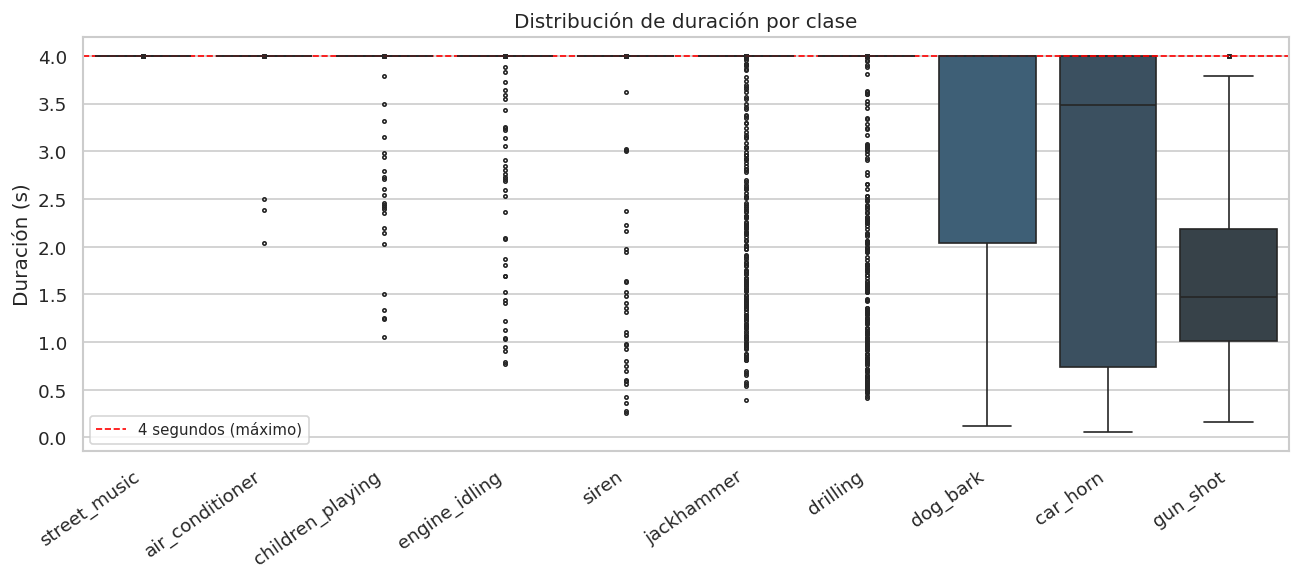

In [20]:
dur_stats = (df.groupby("class")["duration"]
               .agg(["mean", "std", "min", "max"])
               .sort_values("mean", ascending=False)
               .round(3))
print(dur_stats)

# Box plot
order = dur_stats.index.tolist()
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="class", y="duration", order=order,
            palette="Blues_d", flierprops={"marker": ".", "markersize": 4}, ax=ax)
ax.set_title("Distribución de duración por clase")
ax.set_xlabel("")
ax.set_ylabel("Duración (s)")
plt.xticks(rotation=35, ha="right")
ax.axhline(4, color="red", linestyle="--", linewidth=1, label="4 segundos (máximo)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## **8. Salience (prominencia del sonido)**

- `salience = 1` → sonido en primer plano (foreground).
- `salience = 2` → sonido de fondo (background).

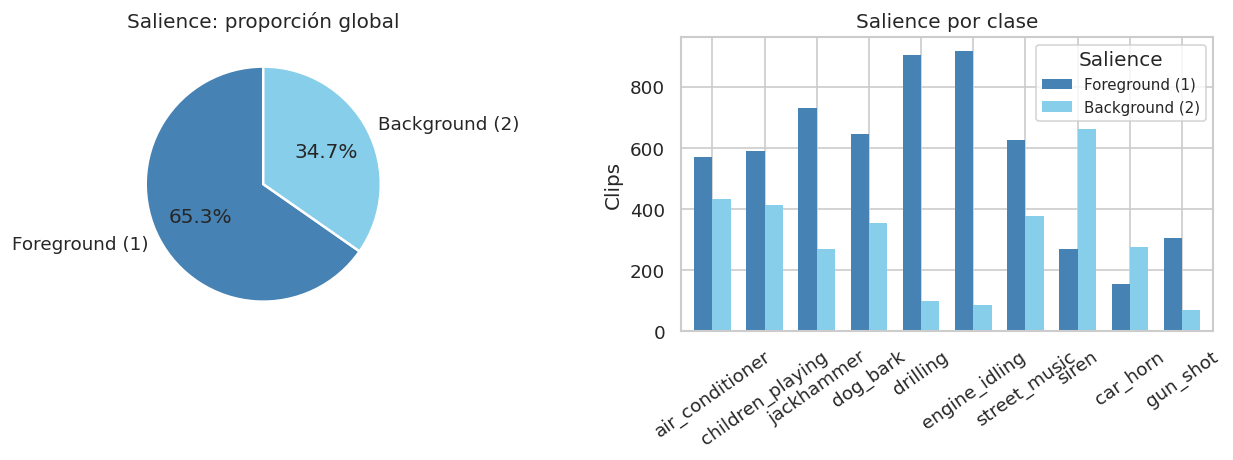

In [21]:
sal = df["salience"].value_counts()
labels = ["Foreground (1)", "Background (2)"]
sizes  = [sal[1], sal[2]]
colors_sal = ["steelblue", "skyblue"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie
axes[0].pie(sizes, labels=labels, colors=colors_sal, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Salience: proporción global")

# Por clase
sal_class = df.groupby(["class", "salience"]).size().unstack(fill_value=0)
sal_class.columns = ["Foreground (1)", "Background (2)"]
sal_class = sal_class.loc[sal_class.sum(axis=1).sort_values(ascending=False).index]
sal_class.plot(kind="bar", ax=axes[1], color=colors_sal, edgecolor="none", width=0.7)
axes[1].set_title("Salience por clase")
axes[1].set_xlabel("")
axes[1].set_ylabel("Clips")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(title="Salience", fontsize=9)
plt.tight_layout()
plt.show()


## **9. Fuentes con más clips (fsID)**

- **Riesgo de data leakage:** si clips del mismo `fsID` quedan en train y test simultáneamente, el modelo puede "memorizar" características del micrófono o del entorno de grabación. Por eso, es **obligatorio** respetar la división por folds provista por los autores del dataset.

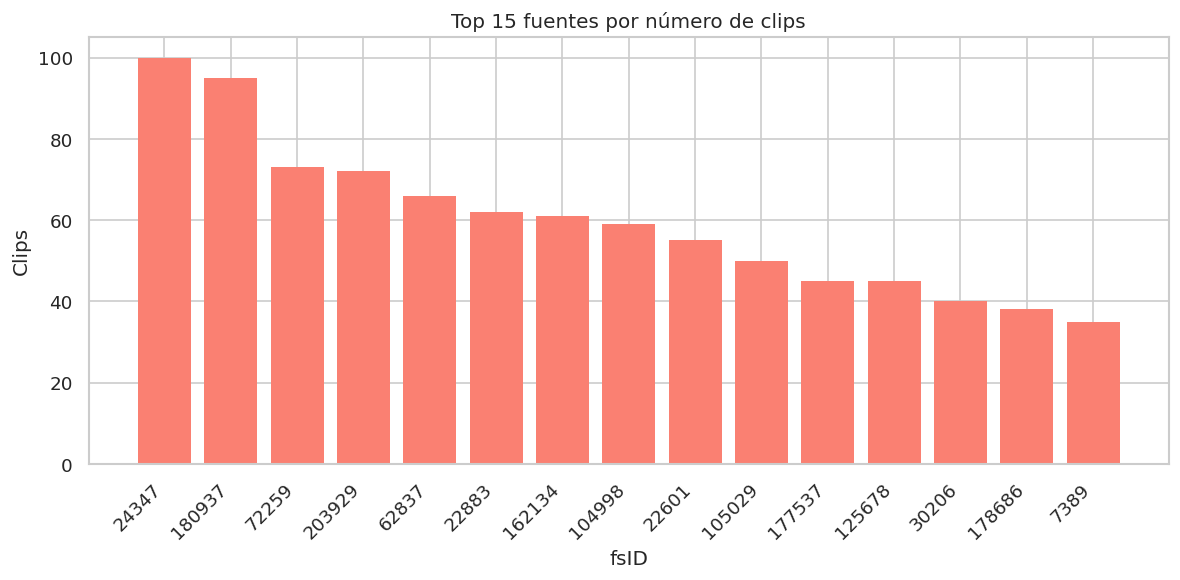

Fuentes únicas: 1297
Media de clips por fuente: 6.73
Fuente más prolífica: fsID 24347 (100 clips)


In [22]:
top_sources = df["fsID"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_sources.index.astype(str), top_sources.values,
       color="salmon", edgecolor="none")
ax.set_title("Top 15 fuentes por número de clips")
ax.set_xlabel("fsID")
ax.set_ylabel("Clips")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Fuentes únicas: {df['fsID'].nunique()}")
print(f"Media de clips por fuente: {df.groupby('fsID').size().mean():.2f}")
print(f"Fuente más prolífica: fsID {df['fsID'].value_counts().idxmax()} "
      f"({df['fsID'].value_counts().max()} clips)")

## **10. Resumen**

| Hallazgo | ¿Qué implica? |
|---|---|
| Dataset desbalanceado (`gun_shot` 374, `car_horn` 429) | Usar class weights o usar oversampling |
| `gun_shot` muy corto (1.65 segundos de media) | Ventanas más cortas en el preprocesado |
| `street_music` siempre dura 4 segundos exactos | Posible sesgo; revisar la diversidad |
| Folds equilibrados (806–990) | Usar 10-fold CV estrictamente; no mezclar folds |
| fsID muy concentrado (top fuente = 100 clips) | No separar en  train/test por clip; separar por fold |
| Sin valores nulos | No se necesita imputar |